# Artificial Neural Networks.

### Neuron:

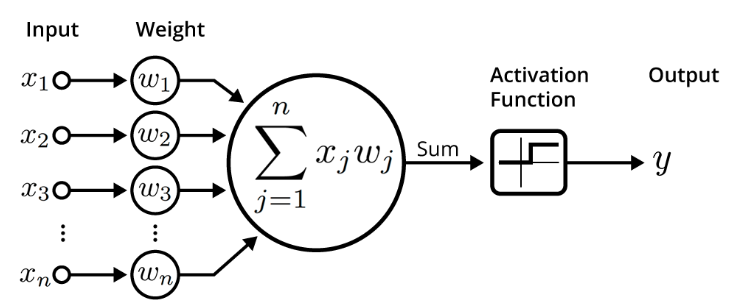

---

## 1. ANN [Artificial Neural Networks]:

- ANN consists of various artificial Neurons connected with each other in the series of layers.

- Mainly there are 3 kindof layers in ANN:
1. Input Layer [First Layer].
2. Hidden Layers.
3. Output Layers.

**Forward Propagation:**

- Linear Transformation.
- Activation.

$$
    z = w_i \cdot x_i + b 
$$
- $w_i$ - Weight associated
- $x_i$ - Features/ Output of previous Layers
- $b$  - bias  
$$
    y_i = f(z)
$$
- $f(z)$ - Activation Function


**Back Propagation:**

- Loss/Error Calculation.
- Gradient of Loss Calculation
- Weight Updation.
- Basically Optimizers are used in backpropagation like SGD, Adam, etc...


In [1]:
import os, warnings
import torch
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

In [2]:
# Device Selection:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
device

'cpu'

In [3]:
# Data Load
df = pd.read_csv(os.path.join('dataset', 'diabetes.csv'))
df.head(5)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [36]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=50)


In [37]:
# Scaling the data:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
X_train.shape

(537, 8)

Building ANN:

In [39]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [45]:
class ANN(nn.Module):
    def __init__(self, input_size):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16,8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

In [46]:
# consisting of ANN Architecture and Forwarding layers...
model = ANN(input_size=X_train.shape[1])

criterion = nn.BCELoss() # Bin. cross entropy loss calculation.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [47]:
EPOCHS = 1000

In [52]:
for epoch in range(EPOCHS):
    
    # converting data type to tensors...
    inputs = torch.tensor(X_train, dtype=torch.float32)
    labels = torch.tensor(y_train, dtype=torch.float32)
    # inputs = X_train
    # labels = y_train
    
    # Forward Propagation:
    outputs = model(inputs)
    loss : nn.BCELoss = criterion(outputs, labels.unsqueeze(1))
    
    # 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch [{epoch+1}/{EPOCHS}]  {'-'*20} Loss: {loss.item():.4f}")
    

Epoch [1/1000]  -------------------- Loss: 0.0105
Epoch [2/1000]  -------------------- Loss: 0.0105
Epoch [3/1000]  -------------------- Loss: 0.0105
Epoch [4/1000]  -------------------- Loss: 0.0104
Epoch [5/1000]  -------------------- Loss: 0.0104
Epoch [6/1000]  -------------------- Loss: 0.0104
Epoch [7/1000]  -------------------- Loss: 0.0104
Epoch [8/1000]  -------------------- Loss: 0.0104
Epoch [9/1000]  -------------------- Loss: 0.0104
Epoch [10/1000]  -------------------- Loss: 0.0104
Epoch [11/1000]  -------------------- Loss: 0.0104
Epoch [12/1000]  -------------------- Loss: 0.0104
Epoch [13/1000]  -------------------- Loss: 0.0104
Epoch [14/1000]  -------------------- Loss: 0.0104
Epoch [15/1000]  -------------------- Loss: 0.0104
Epoch [16/1000]  -------------------- Loss: 0.0104
Epoch [17/1000]  -------------------- Loss: 0.0104
Epoch [18/1000]  -------------------- Loss: 0.0104
Epoch [19/1000]  -------------------- Loss: 0.0104
Epoch [20/1000]  -------------------- Lo

In [53]:
with torch.no_grad():
    y_pred = model(torch.tensor(X_test, dtype = torch.float32))
    y_pred_cls = y_pred.round()
    acc = y_pred_cls.eq(torch.tensor(np.array(y_test), dtype= torch.float32).unsqueeze(1)).sum() / float(y_test.shape[0])
    print(f"Accuracy: {acc:.4f}")

Accuracy: 0.6494
